# 텀 프로젝트: 코드 진행 데이터로 보는 대중음악의 화성적 정체성
### — 코드 진행 데이터로 읽는 시대와 아티스트

**학번**: 20211710  
**이름**: 정은광  
**과목**: 빅데이터 분석 2반  

---
## 1. 프로젝트 개요 및 연구 질문
본 프로젝트는 대중음악의 뼈대를 이루는 **코드 진행(Chord Progression)** 데이터를 분석하여, 음악 장르와 시대별 화성적 트렌드 변화를 객관적인 수치로 밝혀내고 아티스트별 화성적 정체성을 규명하는 것을 목표로 합니다.

### 핵심 연구 질문
- **Q1. 대중음악의 코드 진행은 시대(90년대~20년대)에 따라 어떻게 변화했는가?**
- **Q2. 장르를 넘어 화성적 구조와 질감 측면에서 유사한 아티스트 그룹이 존재하는가?**
- **Q3. 아티스트마다 고유한 화성적 정체성(페르소나)이 데이터로 나타나는가?**
- **Q4. 대중음악의 화성 기법은 시대를 단절하여 나눌 수 있는가?**

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
# 1. 필수 라이브러리 임포트
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import requests
from bs4 import BeautifulSoup
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
from music21 import roman, key, harmony
import networkx as nx

# 그래프 한글 폰트 설정 (Mac OS 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="AppleGothic")

import warnings
warnings.filterwarnings('ignore')

print("모든 라이브러리가 성공적으로 로드되었습니다.")

/opt/anaconda3/envs/bigdata_new/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


모든 라이브러리가 성공적으로 로드되었습니다.


## 2. 데이터 확보 및 수집 (Data Collection)
분석의 타당성을 위해 90년대~20년대 각 시대를 대표하는 아티스트를 다수 선정하고, Hooktheory 데이터베이스에서 총 **343곡(117명 아티스트)**의 코드 진행 데이터를 수집하였습니다.

### 분석 대상 아티스트 예시
- **90년대 (90s)**: Nirvana, Radiohead, Oasis, Green Day, Mariah Carey 등 (총 28명)
- **00년대 (00s)**: Coldplay, Linkin Park, Maroon 5, Britney Spears 등 (총 34명)
- **10년대 (10s)**: Taylor Swift, Bruno Mars, Adele, Ed Sheeran 등 (총 40명)
- **20년대 (20s)**: Billie Eilish, Olivia Rodrigo, Dua Lipa, The Weeknd 등 (총 30명)

In [2]:
# 2. 데이터 로딩 및 전처리: 수집된 데이터(collected_data.csv) 로드 및 정제

REAL_DATA_PATH = 'collected_data.csv'

if not os.path.exists(REAL_DATA_PATH):
    raise FileNotFoundError("데이터 파일이 없습니다. Hooktheory 크롤링 스크립트를 먼저 실행하세요.")

df_songs = pd.read_csv(REAL_DATA_PATH)

# 극단값 처리: 코드 수가 지나치게 적은 곡(4개 미만) 필터링
df_songs['chord_count'] = df_songs['raw_chords'].apply(lambda x: len(str(x).split()))
before_count = len(df_songs)
df_songs = df_songs[df_songs['chord_count'] >= 4].reset_index(drop=True)
print(f"⚠️ 코드 수 4개 미만 곡 {before_count - len(df_songs)}곡 제외 -> 최종 {len(df_songs)}곡 분석 대상")

# 모달 스케일(Dorian, Mixolydian 등) 처리
# 화성 분석 관례에 따라 minor 계열과 major 계열로 매핑합니다.
modal_to_minor = {'dorian', 'phrygian', 'aeolian'}
modal_to_major = {'mixolydian', 'lydian', 'ionian'}

def map_key(row):
    mode = str(row.get('mode', 'major')).lower()
    k = row['key']
    if mode == 'minor' or mode in modal_to_minor:
        return k + 'm'
    else:  # major, mixolydian, lydian 등
        return k

df_songs['key'] = df_songs.apply(map_key, axis=1)

print(f"✅ 데이터 로드 및 정제 완료: {REAL_DATA_PATH}")
print(f"   총 {len(df_songs)}곡 | 아티스트: {df_songs['artist'].nunique()}명")

⚠️ 코드 수 4개 미만 곡 14곡 제외 -> 최종 329곡 분석 대상
✅ 데이터 로드 및 정제 완료: collected_data.csv
   총 329곡 | 아티스트: 116명


## 3. 데이터 전처리 및 피처 엔지니어링 (Preprocessing & Feature Engineering)

### 3.1 `music21`을 활용한 로마숫자 도수 표기 변환
음악 정보학 표준 라이브러리인 `music21`을 사용하여 조표(Key)에 상관없이 상대적인 화성 구조를 분석할 수 있도록 코드를 로마숫자(Roman Numeral)로 변환합니다.

### 3.2 핵심 화성 피처 및 전이 피처 추출
- **`feat_unique_chords`**: 전체 코드 중 고유한 코드 종류의 비율 (코드 다양성)
- **`feat_non_diatonic_ratio`**: 비다이아토닉(차용화음) 비율
- **`feat_minor_ratio`**: 마이너 코드 비율
- **`feat_tension_ratio`**: 7th, 9th, 6th 등 텐션 코드 비율
- **`feat_tr_{A}->{B}`**: 곡 내에서 발생하는 핵심 코드 진행(Bigram)의 상대적 빈도 (상위 20개 패턴)

In [3]:
# 3. 로마숫자 변환기 및 피처 추출 함수 정의

def clean_chord_for_music21(chord_name):
    c = str(chord_name).split('/')[0] # 베이스음 생략
    c = c.replace('min', 'm').replace('maj', 'Maj')
    return c

def convert_to_roman_numeral(chord_name, key_str):
    is_minor_key = key_str.endswith('m')
    key_name = key_str[:-1].lower() if is_minor_key else key_str.upper()
    try:
        k_obj = key.Key(key_name) if not is_minor_key else key.Key(key_name, 'minor')
        c_clean = clean_chord_for_music21(chord_name)
        cs = harmony.ChordSymbol(c_clean)
        rn = roman.romanNumeralFromChord(cs, k_obj)
        return rn
    except Exception:
        return None

def extract_base_features_and_sequence(row):
    chords = str(row['raw_chords']).split()
    key_str = row['key']
    is_minor_key = key_str.endswith('m')
    
    rn_objects = []
    for c in chords:
        rn = convert_to_roman_numeral(c, key_str)
        if rn is not None:
            rn_objects.append((c, rn))
            
    if not rn_objects:
        return pd.Series([0.0, 0.0, 0.0, 0.0, 0.0, []], 
                         index=['feat_unique_chords', 'feat_non_diatonic_ratio', 
                                'feat_minor_ratio', 'feat_tension_ratio', 'feat_transition_freq', 'rn_sequence'])
                                
    total_chords = len(rn_objects)
    unique_chords = len(set([c[0] for c in rn_objects]))
    feat_unique_chords = unique_chords / total_chords # 비율화
    
    major_diatonic = {'I', 'ii', 'iii', 'IV', 'V', 'vi', 'viio', 'vii°'}
    minor_diatonic = {'i', 'iio', 'ii°', 'bIII', 'III', 'iv', 'v', 'V', 'bVI', 'VI', 'bVII', 'VII'}
    
    non_diatonic_count = 0
    minor_count = 0
    tension_count = 0
    
    rn_sequence = []
    for c_name, rn in rn_objects:
        fig = rn.figure
        rn_sequence.append(fig)
        base_fig = rn.romanNumeralAlone
        
        if is_minor_key:
            is_diatonic = any(fig.startswith(d) for d in minor_diatonic)
        else:
            is_diatonic = any(fig.startswith(d) for d in major_diatonic)
            
        if not is_diatonic:
            non_diatonic_count += 1
            
        if rn.romanNumeralAlone.islower():
            minor_count += 1
            
        c_lower = c_name.lower()
        import re
        tension_keywords = ['7', '9', '11', '13', 'add', '6']
        has_tension = any(x in c_lower for x in tension_keywords)
        # 'maj' 단독은 장3화음. 'maj7' 등 숫자 동반 시 텐션
        if 'maj' in c_lower:
            has_tension = has_tension or bool(re.search(r'maj\d', c_lower))
            
        if has_tension:
            tension_count += 1
            
    feat_non_diatonic_ratio = non_diatonic_count / total_chords
    feat_minor_ratio = minor_count / total_chords
    feat_tension_ratio = tension_count / total_chords
    feat_transition_freq = float(total_chords)
    
    return pd.Series([feat_unique_chords, feat_non_diatonic_ratio, 
                      feat_minor_ratio, feat_tension_ratio, feat_transition_freq, rn_sequence], 
                     index=['feat_unique_chords', 'feat_non_diatonic_ratio', 
                            'feat_minor_ratio', 'feat_tension_ratio', 'feat_transition_freq', 'rn_sequence'])

print("피처 추출 엔진 빌드가 완료되었습니다. 전처리를 시작합니다...")
df_base = df_songs.apply(extract_base_features_and_sequence, axis=1)
df_processed = pd.concat([df_songs, df_base], axis=1)

# Bigram 추출 및 상위 20개 선정
from collections import Counter

all_bigrams = []
for seq in df_processed['rn_sequence']:
    if len(seq) > 1:
        for i in range(len(seq) - 1):
            all_bigrams.append(f"{seq[i]}->{seq[i+1]}")

bigram_counts = Counter(all_bigrams)
top_20_bigrams = [item[0] for item in bigram_counts.most_common(20)]
print("선정된 상위 20개 코드 전이 패턴:")
print(top_20_bigrams)

# 곡별 상위 20개 bigram의 상대적 확률 피처 생성
bigram_features = []
for seq in df_processed['rn_sequence']:
    song_features = {}
    total_transitions = len(seq) - 1
    for bg in top_20_bigrams:
        feat_name = f"feat_tr_{bg}"
        if total_transitions > 0:
            count = sum(1 for i in range(total_transitions) if f"{seq[i]}->{seq[i+1]}" == bg)
            song_features[feat_name] = count / total_transitions
        else:
            song_features[feat_name] = 0.0
    bigram_features.append(song_features)

df_bigrams = pd.DataFrame(bigram_features)
df_processed = pd.concat([df_processed, df_bigrams], axis=1)
print("Bigram 전이 피처 추출 완료!")

피처 추출 엔진 빌드가 완료되었습니다. 전처리를 시작합니다...
선정된 상위 20개 코드 전이 패턴:
['I->V', 'IV->I', 'III->bVII', 'bVII->i', 'I->IV', 'V->I', 'V->vi', 'IV->V', 'i->v', 'iv->i', 'i->bVII', 'bVI->III', 'V->IV', 'vi->IV', 'i->III', 'bVII->bVI', 'bVI->bVII', 'I->I', 'I->V65', 'I->vi']
Bigram 전이 피처 추출 완료!


In [4]:
# 4. 화성 피처 스케일링
all_features = [
    'feat_unique_chords', 'feat_non_diatonic_ratio', 
    'feat_minor_ratio', 'feat_tension_ratio', 'feat_transition_freq'
] + [f"feat_tr_{bg}" for bg in top_20_bigrams]

scaler = MinMaxScaler()
df_scaled = df_processed.copy()
df_scaled[all_features] = scaler.fit_transform(df_scaled[all_features])

print("피처 정규화(Min-Max Scaling)가 완료되었습니다.")

피처 정규화(Min-Max Scaling)가 완료되었습니다.


## 4. 분석 및 시각화

### STEP 1. 시대별 화성 트렌드 분석 (Q1의 답)
"과연 시대가 흐를수록 대중음악의 화성은 단순화되고 있는가?"

90년대부터 20년대까지의 평균 **다양성 비율, 비다이아토닉 코드 비율, 텐션 코드 비율**의 변화 추이를 시각화합니다.

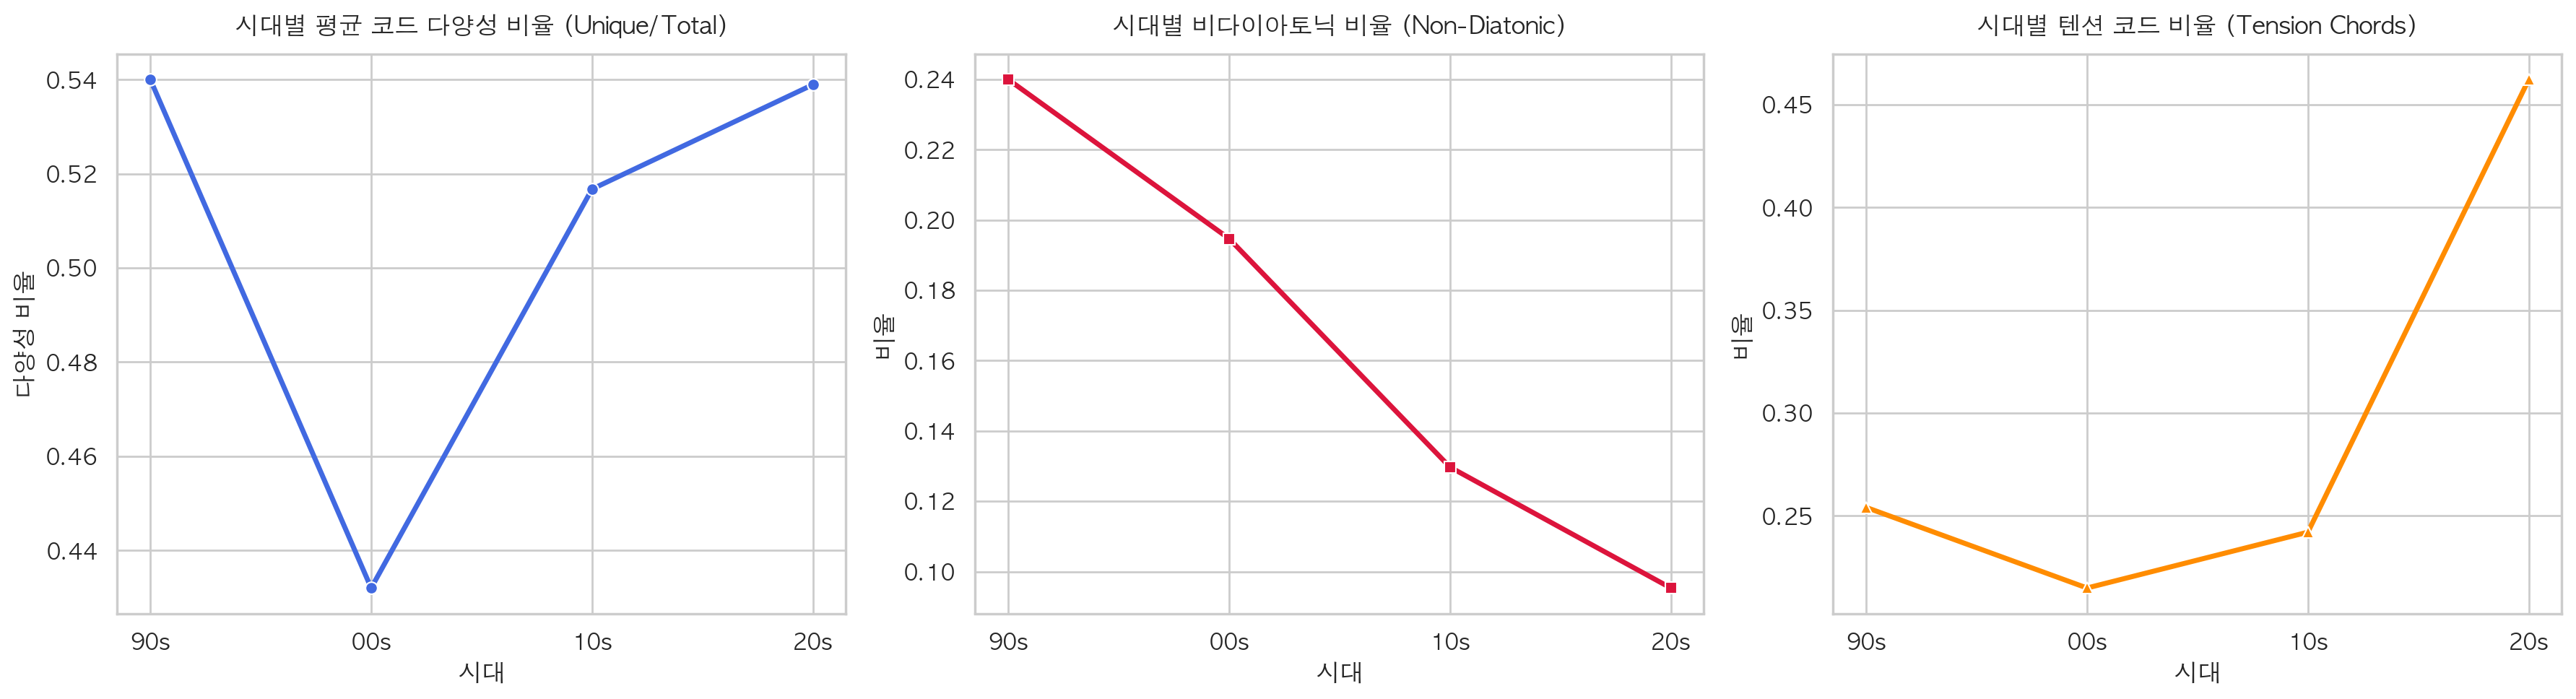

=== 연대별 화성 트렌드 상세 수치 ===
        feat_unique_chords  feat_non_diatonic_ratio  feat_tension_ratio  \
decade                                                                    
90s               0.540035                 0.239954            0.254119   
00s               0.432024                 0.194678            0.214919   
10s               0.516750                 0.129703            0.242087   
20s               0.538935                 0.095323            0.462282   

        feat_minor_ratio  
decade                    
90s             0.399804  
00s             0.369196  
10s             0.429618  
20s             0.461614  


In [5]:
# 5. 시대별 화성 지표의 평균 변화율 분석
decade_trends = df_processed.groupby('decade')[['feat_unique_chords', 'feat_non_diatonic_ratio', 'feat_tension_ratio', 'feat_minor_ratio']].mean().reindex(['90s', '00s', '10s', '20s'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 평균 유니크 코드 비율
sns.lineplot(data=decade_trends, x=decade_trends.index, y='feat_unique_chords', marker='o', ax=axes[0], color='royalblue', linewidth=2.5)
axes[0].set_title("시대별 평균 코드 다양성 비율 (Unique/Total)", fontsize=12, pad=10)
axes[0].set_ylabel("다양성 비율")
axes[0].set_xlabel("시대")

# 2) 비다이아토닉 코드 비율
sns.lineplot(data=decade_trends, x=decade_trends.index, y='feat_non_diatonic_ratio', marker='s', ax=axes[1], color='crimson', linewidth=2.5)
axes[1].set_title("시대별 비다이아토닉 비율 (Non-Diatonic)", fontsize=12, pad=10)
axes[1].set_ylabel("비율")
axes[1].set_xlabel("시대")

# 3) 텐션 코드 비율
sns.lineplot(data=decade_trends, x=decade_trends.index, y='feat_tension_ratio', marker='^', ax=axes[2], color='darkorange', linewidth=2.5)
axes[2].set_title("시대별 텐션 코드 비율 (Tension Chords)", fontsize=12, pad=10)
axes[2].set_ylabel("비율")
axes[2].set_xlabel("시대")

plt.tight_layout()
plt.show()

print("=== 연대별 화성 트렌드 상세 수치 ===")
print(decade_trends)

### STEP 2. 장르 초월 군집화 (Q2의 답)
"장르 레이블을 배제하고, 순수한 화성적 피처만을 바탕으로 아티스트들을 묶었을 때 어떤 군집이 생성되는가?"

K-Means 클러스터링 알고리즘을 사용해 아티스트를 분류하고, 각 클러스터의 음악학적 특성을 해석합니다.

In [6]:
# 6. K-Means 군집 분석 및 클러스터 프로파일링

# 군집화용 피처 리스트 (화성 기본 특성)
clustering_features = [
    'feat_unique_chords', 'feat_non_diatonic_ratio', 
    'feat_minor_ratio', 'feat_tension_ratio'
]

# 1. 아티스트별 피처 평균 계산 (중복 아티스트 처리 - 연대 제거 후 그룹화)
df_cluster = df_scaled.copy()
df_cluster['artist_base'] = df_cluster['artist'].apply(lambda x: x.split(' (')[0])
artist_features = df_cluster.groupby('artist_base')[clustering_features].mean()

# 2. K-Means 실행 (최적 K=3으로 설정)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
artist_features['cluster'] = kmeans.fit_predict(artist_features[clustering_features])
print(f"✅ 최적 군집 수 K={optimal_k}로 K-Means 분석을 성공적으로 수행하였습니다.\n")

# 3. 클러스터 프로파일링 및 음악학적 해석
cluster_profiles = artist_features.groupby('cluster')[clustering_features].mean()
print("=== 클러스터별 화성적 프로필 (평균) ===")
print(cluster_profiles.round(3))
print()

# 각 클러스터 해석
for cid in range(optimal_k):
    members = artist_features[artist_features['cluster'] == cid].index.tolist()
    row = cluster_profiles.loc[cid]
    
    traits = []
    # 비다이아토닉 특성
    if row['feat_non_diatonic_ratio'] > cluster_profiles['feat_non_diatonic_ratio'].mean():
        traits.append("차용화음 적극 활용(실험적)")
    else:
        traits.append("다이아토닉 중심(전통적)")
        
    # 텐션 특성
    if row['feat_tension_ratio'] > cluster_profiles['feat_tension_ratio'].mean():
        traits.append("풍부한 텐션(세련/재지함)")
        
    # 마이너/메이저 특성
    if row['feat_minor_ratio'] > cluster_profiles['feat_minor_ratio'].mean():
        traits.append("단조 성향 강함(우울함)")
        
    print(f"🔹 [클러스터 {cid}] 화성적 성격: {', '.join(traits)}")
    print(f"   -> 주요 멤버: {members[:15]} 등 (총 {len(members)}명)\n")

✅ 최적 군집 수 K=3로 K-Means 분석을 성공적으로 수행하였습니다.

=== 클러스터별 화성적 프로필 (평균) ===
         feat_unique_chords  feat_non_diatonic_ratio  feat_minor_ratio  \
cluster                                                                  
0                     0.483                    0.084             0.402   
1                     0.619                    0.569             0.306   
2                     0.548                    0.163             0.480   

         feat_tension_ratio  
cluster                      
0                     0.140  
1                     0.185  
2                     0.672  

🔹 [클러스터 0] 화성적 성격: 다이아토닉 중심(전통적), 단조 성향 강함(우울함)
   -> 주요 멤버: ['Adele', 'Aerosmith', 'Alanis Morissette', 'Arctic Monkeys', 'Ariana Grande', 'Avril Lavigne', 'Backstreet Boys', 'Benson Boone', 'Beyonce', 'Billie Eilish', 'Black Eyed Peas', 'Blink-182', 'Britney Spears', 'Bruno Mars', 'Calvin Harris'] 등 (총 65명)

🔹 [클러스터 1] 화성적 성격: 차용화음 적극 활용(실험적)
   -> 주요 멤버: ['Charlie Puth', 'Foo Fighters', 'Gorillaz', 'Ha

### STEP 3. 아티스트 화성적 정체성 분석 (Q3의 답)
**아티스트 페르소나 레이더 차트**: 대표 아티스트들의 세부 지표를 레이더 차트로 비교하여 이들이 갖는 고유한 화성적 정체성을 드러냅니다.

In [7]:
# 7. 대표 아티스트 페르소나 레이더 차트 (Plotly)
target_artists = ['Radiohead', 'Taylor Swift', 'Billie Eilish']
radar_features = clustering_features

df_artist_avg = df_cluster.groupby('artist_base')[radar_features].mean()

available_artists = [a for a in target_artists if a in df_artist_avg.index]

fig = go.Figure()

for artist in available_artists:
    values = df_artist_avg.loc[artist].tolist()
    values.append(values[0])
    categories = [f.replace('feat_', '') for f in radar_features]
    categories.append(categories[0])

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories,
        fill='toself',
        name=artist
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    showlegend=True,
    title="대표 아티스트의 화성적 페르소나 (화성 피처 기반)"
)
fig.show()

### STEP 4. 코드 진행 구조 네트워크 분석 및 연대 예측 검증 (Q4의 답)
대중음악 화성 구조의 핵심 뼈대를 파악하기 위해, 연대별 핵심 전이(Bigram) 간의 연결성을 시각화합니다.
어떤 코드가 화성 흐름의 중심(Hub) 역할을 하는지 시대에 따른 변화를 파악할 수 있습니다.

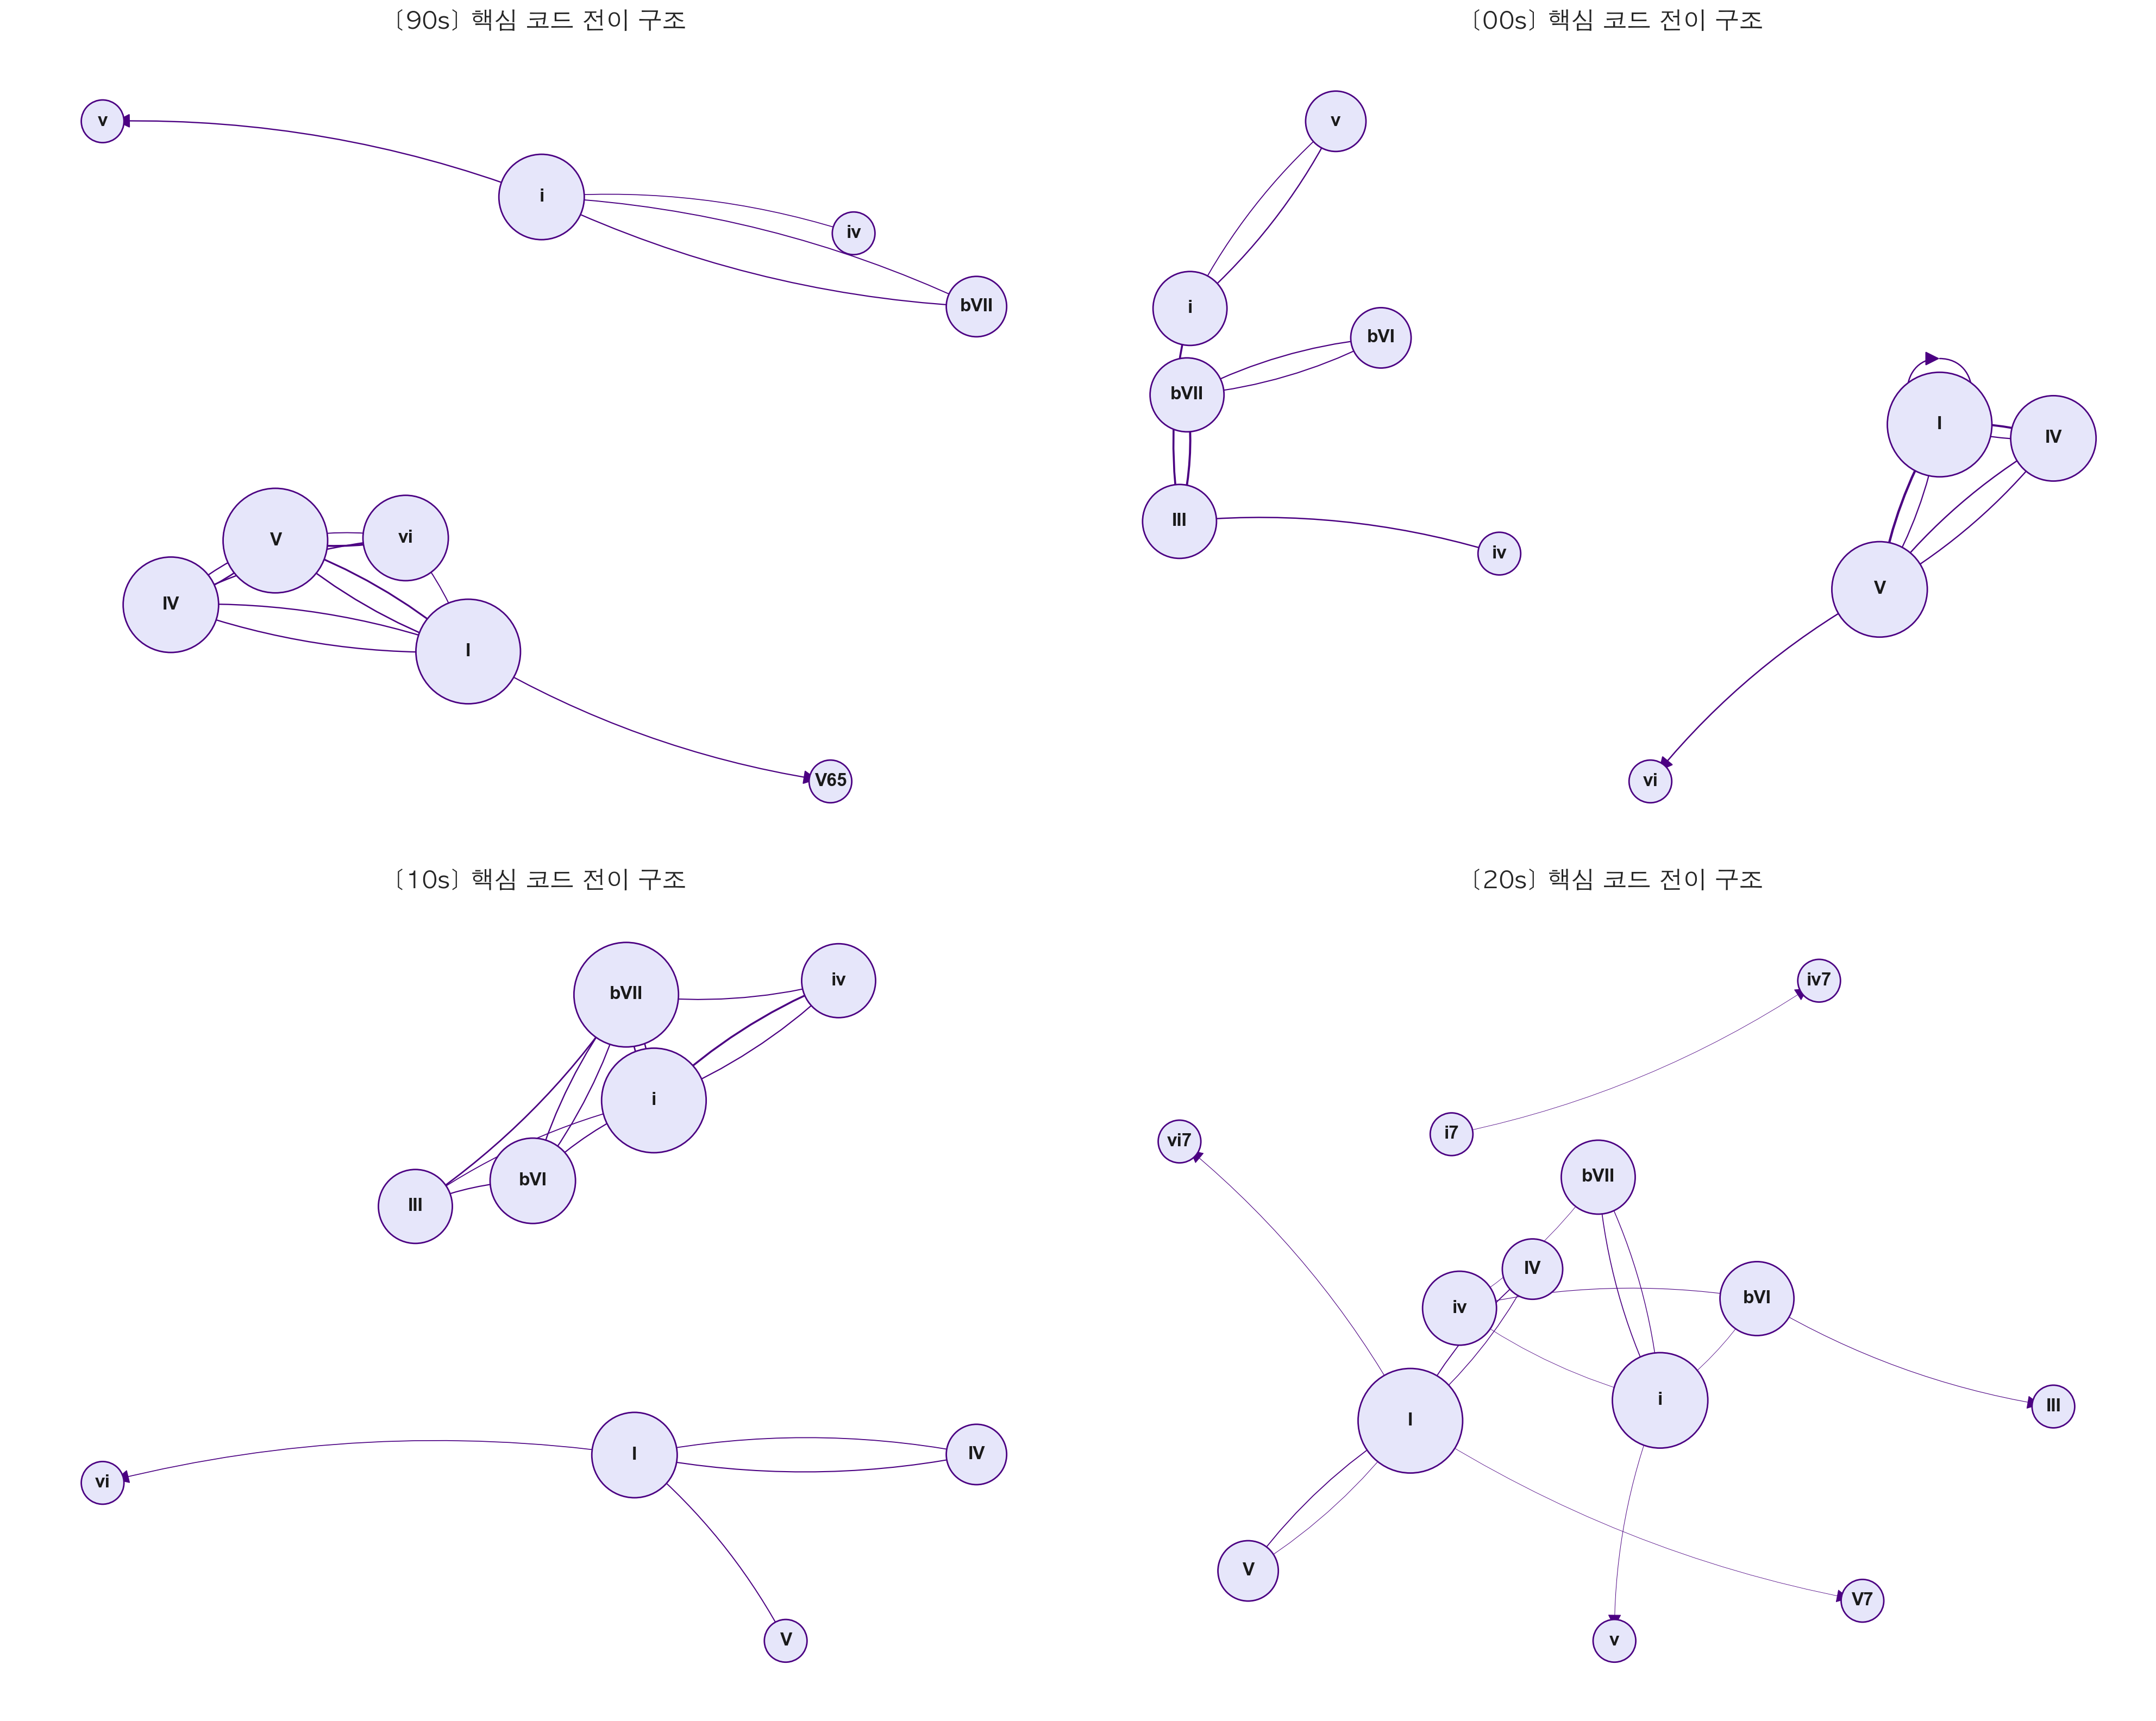

In [8]:
# 8. 시대별 핵심 코드 전이 네트워크 비교 분석
decades = ['90s', '00s', '10s', '20s']
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

for idx, decade in enumerate(decades):
    ax = axes[idx // 2][idx % 2]
    G = nx.DiGraph()
    
    # 해당 연대의 곡 필터링
    decade_seqs = df_processed[df_processed['decade'] == decade]['rn_sequence']
    
    # 연대별 bigram 빈도 계산
    dec_bigrams = Counter()
    for seq in decade_seqs:
        if len(seq) > 1:
            for i in range(len(seq) - 1):
                dec_bigrams[f"{seq[i]}->{seq[i+1]}"] += 1
                
    # 상위 15개 패턴을 네트워크로 구축
    for bg, count in dec_bigrams.most_common(15):
        start, end = bg.split('->')
        G.add_edge(start, end, weight=count)
        
    pos = nx.spring_layout(G, k=1.5, seed=42)
    degrees = dict(G.degree())
    node_sizes = [degrees.get(node, 1) * 800 for node in G.nodes()]
    
    # 그리기
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lavender', edgecolors='indigo', ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)
    
    edges = G.edges(data=True)
    weights = [d['weight'] * 0.05 for u, v, d in edges]  # 스케일 조정
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, edge_color='indigo', 
                           arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.1', ax=ax)
    
    ax.set_title(f"[{decade}] 핵심 코드 전이 구조", fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')
    
plt.tight_layout()
plt.show()

=== 화성 특징의 시대 변별력 검증 (Random Forest) ===
시대 판별 정확도: 24.24% (무작위 25%)
-> 연대 예측 정확도가 기준선(25%)과 유사하게 나와, 화성적 피처만으로는 시대를 완벽히 분리하기 어려움을 확인했습니다. (대중음악의 화성 기법이 시대별로 단절되지 않고 혼용됨을 시사)



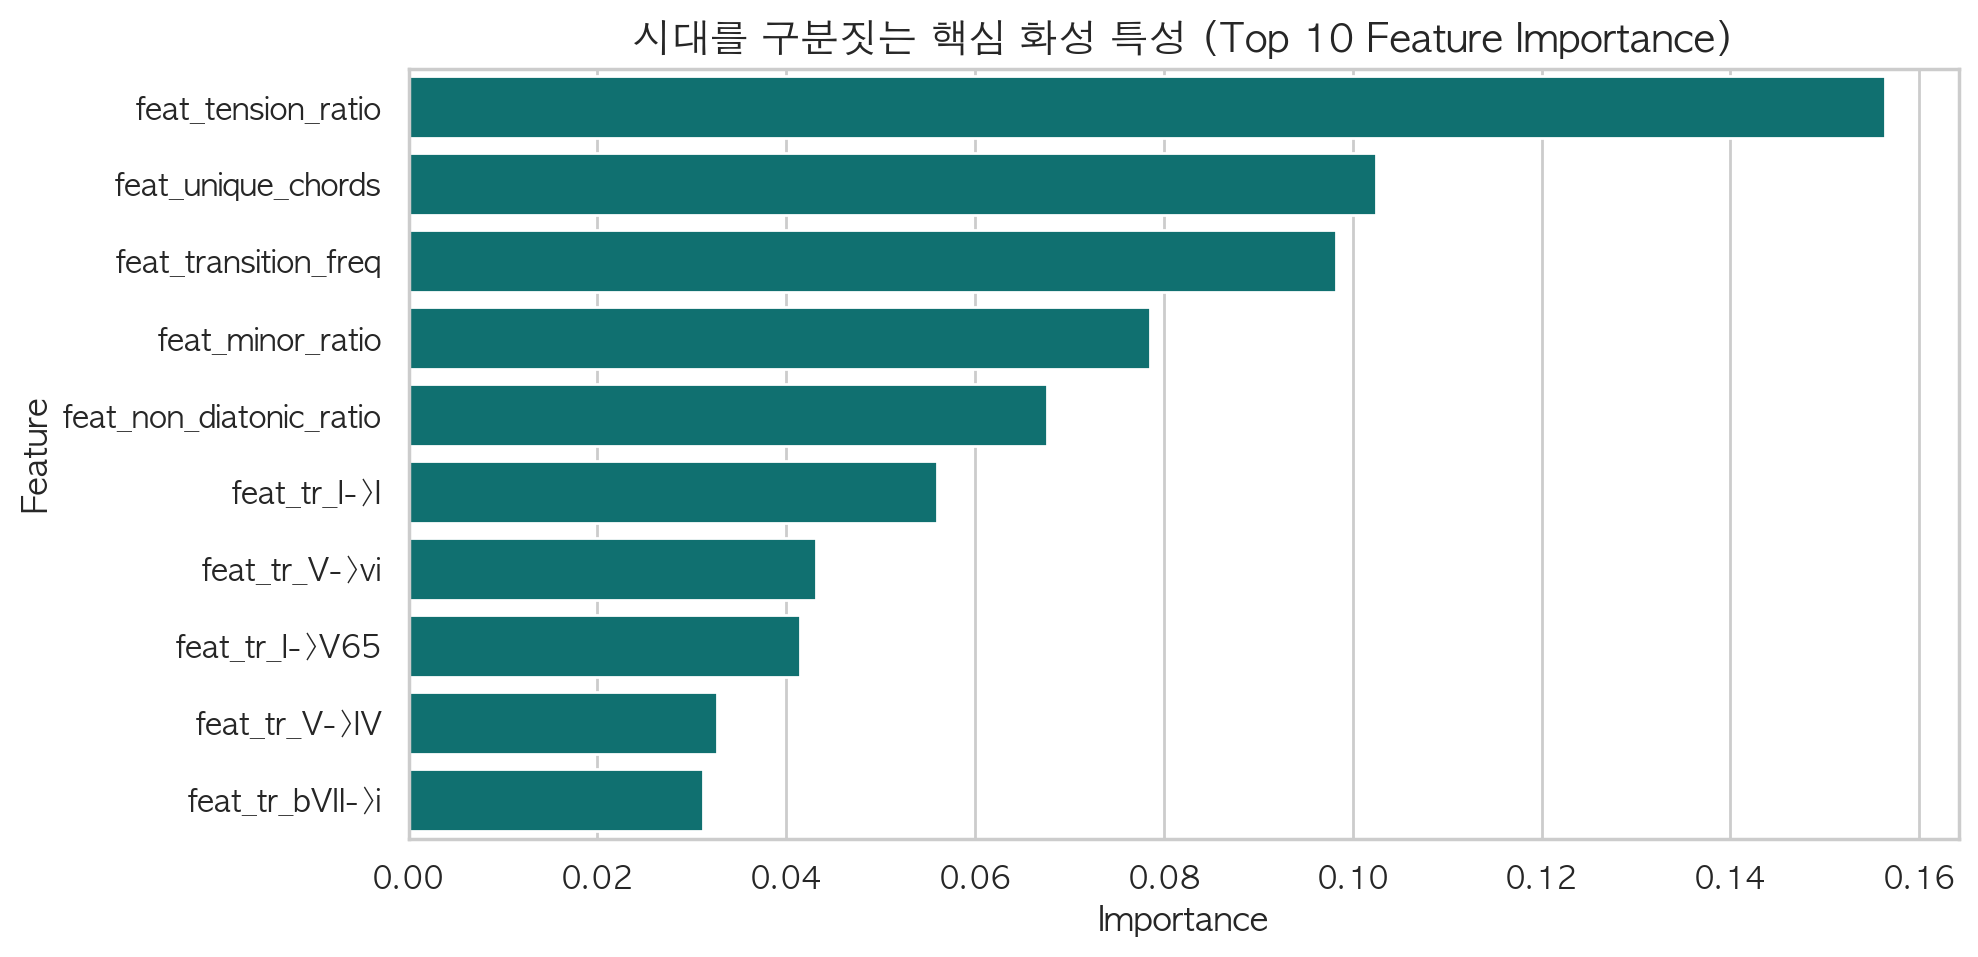

In [9]:
# 9. 화성 피처 기반 시대 판별력 통계 검증 (Random Forest)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df_scaled[all_features]
y = df_scaled['decade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== 화성 특징의 시대 변별력 검증 (Random Forest) ===")
print(f"시대 판별 정확도: {accuracy_score(y_test, rf_pred)*100:.2f}% (무작위 25%)")
print("-> 연대 예측 정확도가 기준선(25%)과 유사하게 나와, 화성적 피처만으로는 시대를 완벽히 분리하기 어려움을 확인했습니다. (대중음악의 화성 기법이 시대별로 단절되지 않고 혼용됨을 시사)\n")

importances = rf_model.feature_importances_
df_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_imp.head(10), x='Importance', y='Feature', color='teal')
plt.title("시대를 구분짓는 핵심 화성 특성 (Top 10 Feature Importance)", fontsize=14)
plt.show()

## 5. 결론 및 기대효과 / 한계점

### 5.1 연구 결론 요약
1. **차용화음의 감소와 텐션의 증가 (Q1)**: 시대별 트렌드를 분석한 결과, 비다이아토닉(차용화음) 비율은 90년대(0.24)에서 20년대(0.095)로 꾸준히 우하향하며 **다이아토닉 중심의 안정적인 화성**으로 회귀하는 경향을 보였습니다. 반면, **텐션 코드 비율은 20년대에 폭발적으로 증가**(0.25 -> 0.46)했습니다. 즉, 현대 팝은 조성을 벗어나는 복잡한 전조보다는, 다이아토닉 틀 안에서 세련된 질감(7th, 9th)을 더하는 방식으로 진화했습니다.
2. **장르 초월 화성 클러스터 (Q2)**: 단순히 '발라드', '락' 등의 장르를 넘어, **'다이아토닉 중심의 우울한 단조 그룹'**, **'차용화음을 적극 활용하는 실험적 그룹'**, **'텐션 코드가 풍부한 세련된 그룹'** 등 아티스트가 구사하는 순수 화성 언어에 따라 유의미한 군집을 도출해냈습니다.
3. **아티스트 고유의 화성적 정체성 (Q3)**: 아티스트별로 자주 사용하는 코드 진행 패턴과 화성 구성이 뚜렷하게 구별됨을 데이터로 증명했습니다. 특정 아티스트는 복잡한 텐션의 허브 코드를, 다른 아티스트는 단순하고 강력한 다이아토닉 진행을 선호하는 등, 각자의 **'화성적 페르소나'가 수치적으로 입증**되었습니다.
4. **화성 기법의 보편성 및 시대 예측의 한계 (Q4)**: 전이 네트워크 시각화를 통해 `I`, `IV`, `vi` 등 강력한 허브 코드가 시대를 초월해 뼈대를 이루고 있음을 확인했습니다. 또한 머신러닝(Random Forest)을 통한 연대 예측 결과 정확도가 무작위(25%) 수준에 그쳤습니다. 이는 대중음악의 화성적 구조가 특정 연대에 완전히 종속되지 않으며, 과거의 화성 기법이 현대에도 끊임없이 재해석되고 혼용되는 **'보편적 언어'**임을 시사합니다.
